In [1]:
import pandas as pd

In [2]:
path = '../data/processed/cleaned_data.csv'
dataset = pd.read_csv(path)

In [3]:
dataset.head(3)

,Geography_Germany,Geography_Spain,Gender_Male,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.0,0.0,0.0,619,42,2,0.00,1,1,1,101348.88,1
1,0.0,1.0,0.0,608,41,1,83807.86,1,0,1,112542.58,0
2,0.0,0.0,0.0,502,42,8,159660.80,3,1,0,113931.57,1


In [4]:
x = dataset.drop('Exited', axis = 1)
y = dataset['Exited']

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [7]:
from sklearn.ensemble import RandomForestClassifier

In [8]:
rfc = RandomForestClassifier(n_estimators = 300, class_weight = 'balanced', random_state = 42, max_depth = 9, min_samples_leaf = 3, min_samples_split = 17, max_features='sqrt')

In [9]:
rfc.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",17
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [10]:
rfc.score(x_train, y_train) * 100, rfc.score(x_test, y_test) * 100

(86.575, 83.75)

In [11]:
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, precision_score, f1_score

In [12]:
y_pred = rfc.predict(x_test)

In [13]:
accuracy_score(y_test, y_pred) * 100

83.75

In [14]:
recall_score(y_test, y_pred) * 100

71.50127226463104

In [15]:
precision_score(y_test, y_pred) * 100

56.882591093117405

In [16]:
f1_score(y_test, y_pred) * 100

63.35963923337091

In [25]:
cm = confusion_matrix(y_test, y_pred)

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

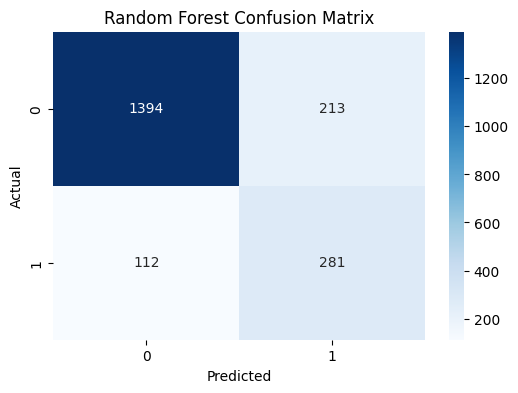

In [30]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../reports/random_forest_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rfc.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

              Feature  Importance
4                 Age    0.354991
7       NumOfProducts    0.240946
6             Balance    0.108971
9      IsActiveMember    0.062961
10    EstimatedSalary    0.057651
3         CreditScore    0.053772
0   Geography_Germany    0.051037
5              Tenure    0.031514
2         Gender_Male    0.022930
1     Geography_Spain    0.007828
8           HasCrCard    0.007399


In [32]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

In [35]:
metrics_df.to_csv("../reports/random_forest_metrics.csv", index=False)

In [36]:
import joblib

In [37]:
joblib.dump(rfc, "../models/random_forest.pkl")

['../models/random_forest.pkl']